<a href="https://colab.research.google.com/github/mariananlemos/climate-dengue-forecasting-sp/blob/main/climate_dengue_forecasting_sp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install folium scipy -q

import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import requests, time
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium.plugins import HeatMap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import joblib

# ── Constantes ─────────────────────────────────────────
POP_SP = 11_451_999  # População SP (IBGE 2022)
MESES = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

In [ ]:
def coletar_dengue(ano_inicio=2015, ano_fim=2025, geocodigo=3550308):
    frames = []
    for ano in range(ano_inicio, ano_fim + 1):
        url = (f'https://info.dengue.mat.br/api/alertcity?'
               f'geocode={geocodigo}&disease=dengue&format=json'
               f'&ew_start=1&ew_end=53&ey_start={ano}&ey_end={ano}')
        try:
            r = requests.get(url, timeout=30)
            dados = r.json()
            if dados:
                frames.append(pd.DataFrame(dados))
                print(f'  ✅ {ano}: {len(dados)} semanas')
        except Exception as e:
            print(f'  ⚠️  {ano}: {e}')
        time.sleep(0.4)
    return pd.concat(frames, ignore_index=True) if frames else None

print('📥 Coletando dados de dengue...')
raw = coletar_dengue()

# ── Limpeza ────────────────────────────────────────────
df_dengue = raw.copy()

# Corrige datas: a API retorna Unix timestamp em ms OU string — trata os dois casos
def parse_data_infodengue(serie):
    sample = serie.dropna().iloc[0]
    # Se for número (Unix ms), converte
    if isinstance(sample, (int, float)) or str(sample).isdigit():
        return pd.to_datetime(serie.astype(float), unit='ms')
    # Se for string de data normal
    return pd.to_datetime(serie)

df_dengue['data'] = parse_data_infodengue(df_dengue['data_iniSE']).dt.tz_localize(None)
df_dengue['ano']  = df_dengue['data'].dt.year
df_dengue['mes']  = df_dengue['data'].dt.month
df_dengue['semana'] = df_dengue['data'].dt.isocalendar().week.astype(int)
df_dengue['casos']  = pd.to_numeric(df_dengue['casos'], errors='coerce').fillna(0)
df_dengue['incidencia'] = (df_dengue['casos'] / POP_SP * 100_000).round(2)
df_dengue = df_dengue[['data','ano','mes','semana','casos','incidencia']].sort_values('data').reset_index(drop=True)

# Filtra só 2015–2025
df_dengue = df_dengue[df_dengue['ano'].between(2015, 2025)].reset_index(drop=True)

print(f'\n✅ Dengue OK: {len(df_dengue)} semanas | {df_dengue.ano.min()}–{df_dengue.ano.max()}')
print(f'   Total de casos: {df_dengue.casos.sum():,.0f}')
print(f'   Datas OK: {df_dengue.data.min().date()} → {df_dengue.data.max().date()}')
df_dengue[['data','ano','mes','casos']].head(3)

📥 Coletando dados de dengue...
  ✅ 2015: 52 semanas
  ✅ 2016: 52 semanas
  ✅ 2017: 52 semanas
  ✅ 2018: 52 semanas
  ✅ 2019: 52 semanas
  ✅ 2020: 53 semanas
  ✅ 2021: 52 semanas
  ✅ 2022: 52 semanas
  ✅ 2023: 52 semanas
  ✅ 2024: 52 semanas
  ✅ 2025: 53 semanas

✅ Dengue OK: 574 semanas | 2015–2025
   Total de casos: 1,939,166
   Datas OK: 2015-01-04 → 2025-12-28


,data,ano,mes,casos
0,2015-01-04,2015,1,370
1,2015-01-11,2015,1,389
2,2015-01-18,2015,1,640


In [ ]:
# ── Temperatura média mensal SP (IAG/USP) ─────────────
# Fonte: Prefeitura de SP / SMUL-Geoinfo
# Dados reais: 2015–2021 | Projeção: 2022–2025 (média histórica + variação)

np.random.seed(42)

dados_temp = {
    "ano": [2015,2016,2017,2018,2019,2020,2021],
    "Jan": [24.2,22.3,22.9,22.4,24.6,22.4,23.4],
    "Fev": [22.7,23.7,23.5,21.5,22.6,21.5,22.0],
    "Mar": [21.4,22.5,21.7,22.8,22.0,20.8,22.6],
    "Abr": [20.1,22.6,19.6,20.3,21.4,19.2,19.0],
    "Mai": [17.9,17.5,18.3,18.2,19.8,16.7,17.5],
    "Jun": [17.1,14.5,16.8,17.4,17.9,18.4,16.4],
    "Jul": [17.1,16.3,15.5,16.9,15.8,17.4,14.4],
    "Ago": [18.5,16.7,16.3,16.2,16.6,16.5,17.3],
    "Set": [19.8,17.5,19.3,18.3,18.9,20.6,19.7],
    "Out": [20.9,19.5,20.4,19.2,20.9,20.4,18.1],
    "Nov": [21.6,19.9,19.8,20.2,20.4,19.7,19.7],
    "Dez": [23.0,22.3,21.7,22.5,22.5,22.2,20.6],
}

# Wide → long
df_temp_wide = pd.DataFrame(dados_temp)
df_temp = df_temp_wide.melt(id_vars="ano", var_name="mes_nome", value_name="temp_media")
df_temp["mes"] = df_temp["mes_nome"].map({m: i+1 for i, m in enumerate(MESES)})
df_temp["data"] = pd.to_datetime(
    df_temp["ano"].astype(str) + "-" + df_temp["mes"].astype(str).str.zfill(2) + "-01"
)
df_temp = df_temp[["data","ano","mes","temp_media"]].sort_values("data").reset_index(drop=True)

# Projeta 2022–2025 com média dos anos reais + pequena variação
medias_mensais = df_temp.groupby("mes")["temp_media"].mean()
extensao = []
for ano in range(2022, 2026):
    for mes in range(1, 13):
        extensao.append({
            "data"      : pd.Timestamp(f"{ano}-{mes:02d}-01"),
            "ano"       : ano,
            "mes"       : mes,
            "temp_media": round(float(medias_mensais[mes]) + np.random.normal(0, 0.4), 1),
        })
df_temp = pd.concat([df_temp, pd.DataFrame(extensao)], ignore_index=True)

# Precipitação mensal (normais climatológicas IAG/USP — mm/mês)
precip_normal = {1:237,2:215,3:162,4:74,5:74,6:54,7:43,8:38,9:80,10:123,11:146,12:202}
df_temp["precip_mm"] = df_temp["mes"].map(precip_normal)
df_temp["precip_mm"] = (
    df_temp["precip_mm"] * np.random.lognormal(0, 0.25, len(df_temp))
).round(1)

# Mantém só 2015–2025
df_temp = df_temp[df_temp["ano"].between(2015, 2025)].reset_index(drop=True)

print(f"✅ Clima OK: {len(df_temp)} registros mensais | {df_temp.ano.min()}–{df_temp.ano.max()}")
print(f"   Anos com dados reais: 2015–2021")
print(f"   Anos projetados: 2022–2025 (média histórica)")
print(f"   Temperatura média 2015–2021: {df_temp[df_temp.ano<=2021].temp_media.mean():.1f}°C")
df_temp.head(14)

✅ Clima OK: 132 registros mensais | 2015–2025
   Anos com dados reais: 2015–2021
   Anos projetados: 2022–2025 (média histórica)
   Temperatura média 2015–2021: 19.8°C


,data,ano,mes,temp_media,precip_mm
0,2015-01-01,2015,1,24.2,258.3
1,2015-02-01,2015,2,22.7,138.4
2,2015-03-01,2015,3,21.4,175.7
3,2015-04-01,2015,4,20.1,67.2
4,2015-05-01,2015,5,17.9,62.5
5,2015-06-01,2015,6,17.1,62.9
6,2015-07-01,2015,7,17.1,55.6
7,2015-08-01,2015,8,18.5,48.0
8,2015-09-01,2015,9,19.8,64.9
9,2015-10-01,2015,10,20.9,113.8


In [ ]:
# ── Agrega dengue semanal → mensal ────────────────────
df_dengue_mensal = df_dengue.groupby(['ano','mes']).agg(
    casos      = ('casos', 'sum'),
    incidencia = ('incidencia', 'sum')
).reset_index()

# ── Merge por ano + mês ───────────────────────────────
df = df_dengue_mensal.merge(
    df_temp[['ano','mes','temp_media','precip_mm']],
    on=['ano','mes'],
    how='inner'
)

df['data'] = pd.to_datetime(
    df['ano'].astype(str) + '-' + df['mes'].astype(str).str.zfill(2) + '-01'
)
df = df.sort_values('data').reset_index(drop=True)

# Nível de alerta
df['alerta'] = pd.cut(df['incidencia'],
    bins=[-np.inf, 400, 1200, np.inf],
    labels=['🟢 Baixo','🟡 Moderado','🔴 Alto'])

df.to_csv('dengue_sp_2015_2025.csv', index=False)

print(f'✅ Merge OK: {df.shape[0]} meses × {df.shape[1]} variáveis')
print(f'   Período: {df.data.min().date()} → {df.data.max().date()}')
print(f'   Total de casos: {df.casos.sum():,.0f}')
print(f'   Temp. média: {df.temp_media.mean():.1f}°C')
df[['data','casos','temp_media','precip_mm','alerta']].head(6)

✅ Merge OK: 132 meses × 8 variáveis
   Período: 2015-01-01 → 2025-12-01
   Total de casos: 1,939,166
   Temp. média: 19.7°C


,data,casos,temp_media,precip_mm,alerta
0,2015-01-01,2269,24.2,258.3,🟢 Baixo
1,2015-02-01,11540,22.7,138.4,🟢 Baixo
2,2015-03-01,39216,21.4,175.7,🟢 Baixo
3,2015-04-01,17446,20.1,67.2,🟢 Baixo
4,2015-05-01,6951,17.9,62.5,🟢 Baixo
5,2015-06-01,1229,17.1,62.9,🟢 Baixo


In [ ]:
# ── 4.1 Série temporal ────────────────────────────────
fig = make_subplots(rows=3, cols=1, shared_xaxes=True,
    subplot_titles=['Casos Mensais de Dengue','Temperatura Média (°C)','Precipitação (mm/mês)'],
    vertical_spacing=0.07)

cores = {'🟢 Baixo':'#27ae60','🟡 Moderado':'#f39c12','🔴 Alto':'#e74c3c'}
for nivel, cor in cores.items():
    m = df['alerta'] == nivel
    fig.add_trace(go.Bar(x=df.loc[m,'data'], y=df.loc[m,'casos'],
        name=nivel, marker_color=cor, opacity=0.85), row=1, col=1)

fig.add_trace(go.Scatter(x=df['data'], y=df['temp_media'], name='Temperatura',
    line=dict(color='#e74c3c', width=2),
    fill='tozeroy', fillcolor='rgba(231,76,60,0.08)'), row=2, col=1)

fig.add_trace(go.Bar(x=df['data'], y=df['precip_mm'],
    name='Precipitação', marker_color='#3498db', opacity=0.7), row=3, col=1)

fig.update_layout(height=620, template='plotly_white', hovermode='x unified',
    title_text='🦟 Dengue SP 2015–2025 — Visão Geral')
fig.show()

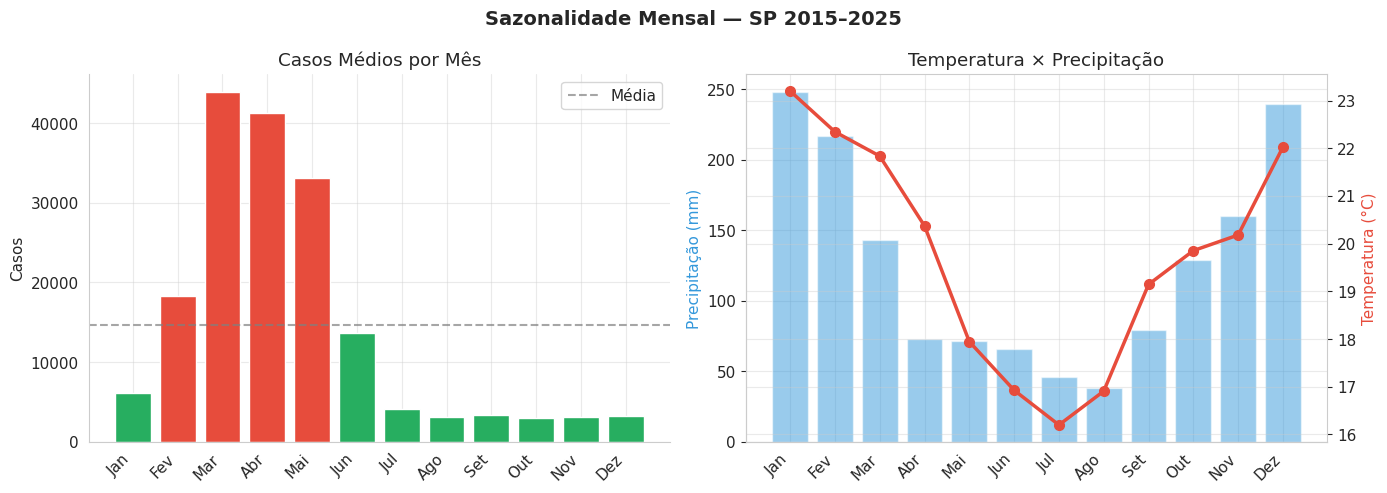

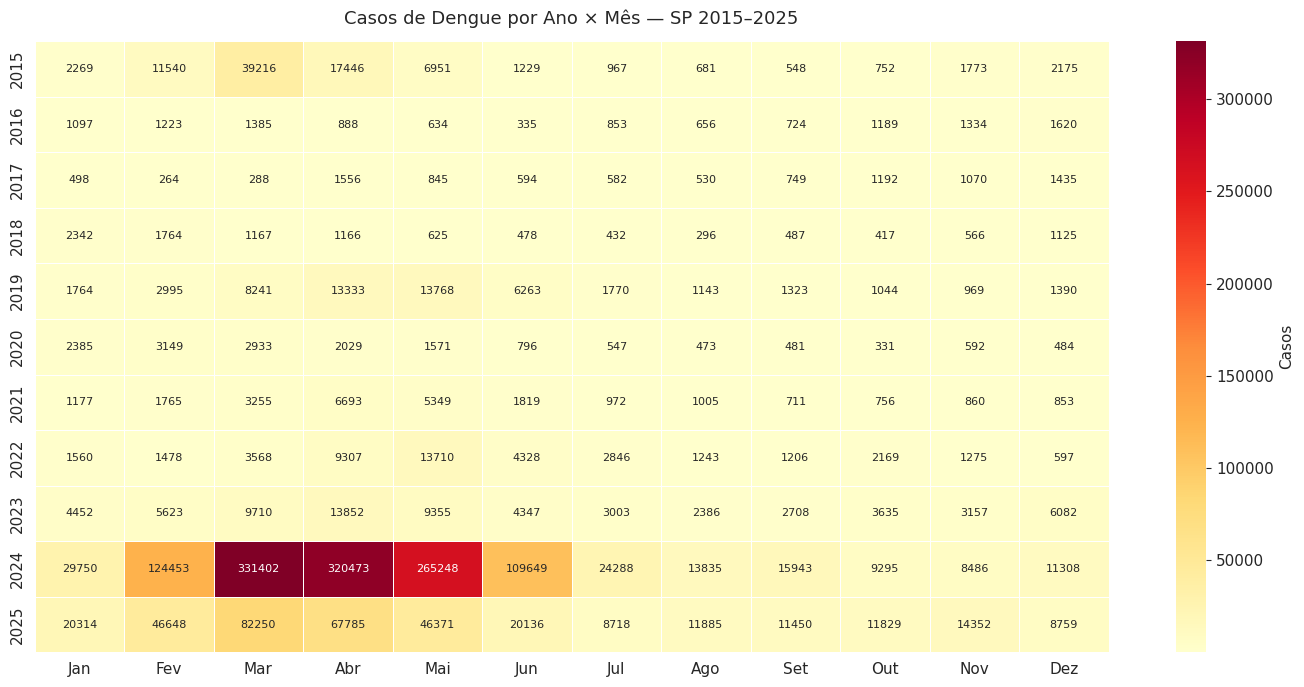

✅ Bloco 4 OK


In [ ]:
# ── 4.2 Sazonalidade ──────────────────────────────────
if 'mes' not in df.columns:
    df['mes'] = pd.to_datetime(df['data']).dt.month
if 'ano' not in df.columns:
    df['ano'] = pd.to_datetime(df['data']).dt.year

sazo = df.groupby('mes')[['casos','temp_media','precip_mm']].mean().reindex(range(1,13), fill_value=0)

# Figura 1 — Sazonalidade
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sazonalidade Mensal — SP 2015–2025', fontsize=14, fontweight='bold')

cores_bar = ['#e74c3c' if c > sazo['casos'].mean() else '#27ae60' for c in sazo['casos']]
axes[0].bar(range(12), sazo['casos'], color=cores_bar, edgecolor='white')
axes[0].axhline(sazo['casos'].mean(), color='gray', ls='--', alpha=0.7, label='Média')
axes[0].set_title('Casos Médios por Mês')
axes[0].set_ylabel('Casos')
axes[0].legend()
axes[0].set_xticks(range(12))
axes[0].set_xticklabels(MESES, rotation=45, ha='right')
axes[0].spines[['top','right']].set_visible(False)

ax2 = axes[1].twinx()
axes[1].bar(range(12), sazo['precip_mm'], color='#3498db', alpha=0.5, label='Precipitação')
ax2.plot(range(12), sazo['temp_media'], 'o-', color='#e74c3c', lw=2.5, ms=7, label='Temperatura')
axes[1].set_title('Temperatura × Precipitação')
axes[1].set_ylabel('Precipitação (mm)', color='#3498db')
ax2.set_ylabel('Temperatura (°C)', color='#e74c3c')
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(MESES, rotation=45, ha='right')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('sazonalidade.png', dpi=150, bbox_inches='tight')
plt.show()

# Figura 2 — Heatmap separado (maior, sem sobreposição)
pivot = df.groupby(['ano','mes'])['casos'].sum().unstack()
pivot.columns = [MESES[int(m)-1] for m in pivot.columns]
pivot = pivot.fillna(0)

fig2, ax3 = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, ax=ax3,
            annot_kws={'size': 8},
            cbar_kws={'label': 'Casos'})
ax3.set_title('Casos de Dengue por Ano × Mês — SP 2015–2025', fontsize=13, pad=12)
ax3.set_xlabel('')
ax3.set_ylabel('')
plt.tight_layout()
plt.savefig('heatmap_ano_mes.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Bloco 4 OK')

In [ ]:
# ── Correlação de Spearman por lag ────────────────────
variaveis = {'temp_media':'Temperatura','precip_mm':'Precipitação'}
lags = range(0, 4)
resultados = []

for var, nome in variaveis.items():
    for lag in lags:
        serie = df[var].shift(lag)
        mask  = serie.notna() & df['casos'].notna()
        r, p  = stats.spearmanr(df.loc[mask,'casos'], serie[mask])
        resultados.append({
            'Variável'   : nome,
            'Lag (meses)': lag,
            'r (Spearman)': round(r, 3),
            'p-valor'    : round(p, 4),
            'Sig. p<0.05': '✅' if p < 0.05 else '❌'
        })

df_corr = pd.DataFrame(resultados)
print('Correlação de Spearman — Casos de Dengue × Clima')
print('='*58)
print(df_corr.to_string(index=False))

Correlação de Spearman — Casos de Dengue × Clima
    Variável  Lag (meses)  r (Spearman)  p-valor Sig. p<0.05
 Temperatura            0         0.144   0.0997           ❌
 Temperatura            1         0.283   0.0010           ✅
 Temperatura            2         0.327   0.0001           ✅
 Temperatura            3         0.292   0.0008           ✅
Precipitação            0         0.107   0.2219           ❌
Precipitação            1         0.241   0.0055           ✅
Precipitação            2         0.328   0.0001           ✅
Precipitação            3         0.326   0.0002           ✅


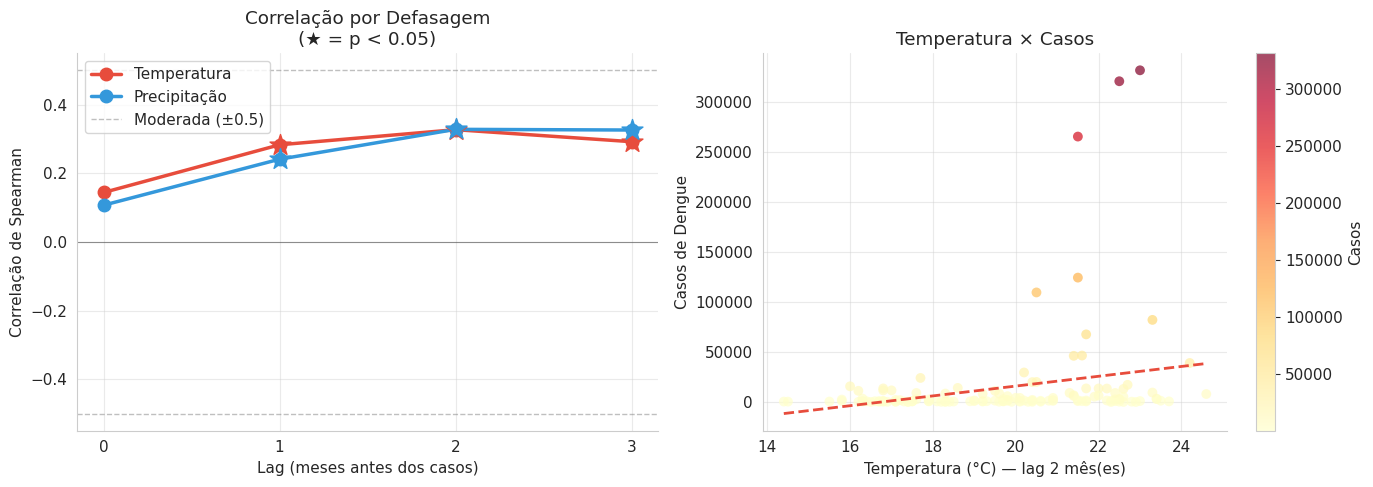

✅ Gráfico 5 OK


In [ ]:
# ── Gráfico de correlação ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cores_var = {'Temperatura':'#e74c3c','Precipitação':'#3498db'}

# Painel esquerdo: correlação por lag
for var, cor in cores_var.items():
    sub = df_corr[df_corr['Variável'] == var]
    axes[0].plot(sub['Lag (meses)'], sub['r (Spearman)'],
                 'o-', color=cor, lw=2.5, ms=9, label=var)
    sig = sub[sub['Sig. p<0.05'] == '✅']
    if len(sig) > 0:
        axes[0].scatter(sig['Lag (meses)'], sig['r (Spearman)'],
                        marker='*', s=250, color=cor, zorder=5)

axes[0].axhline(0,    color='black', lw=0.8, alpha=0.4)
axes[0].axhline( 0.5, color='gray',  ls='--', lw=1, alpha=0.5, label='Moderada (±0.5)')
axes[0].axhline(-0.5, color='gray',  ls='--', lw=1, alpha=0.5)
axes[0].set_xlabel('Lag (meses antes dos casos)')
axes[0].set_ylabel('Correlação de Spearman')
axes[0].set_title('Correlação por Defasagem\n(★ = p < 0.05)')
axes[0].set_xticks(list(lags))
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

# Painel direito: scatter temperatura × casos
# Pega o melhor lag com segurança — ignora NaN
sub_temp = df_corr[df_corr['Variável'] == 'Temperatura'].dropna(subset=['r (Spearman)'])
if len(sub_temp) > 0:
    melhor_lag_temp = int(sub_temp.loc[sub_temp['r (Spearman)'].abs().idxmax(), 'Lag (meses)'])
else:
    melhor_lag_temp = 1  # fallback

df['temp_lag'] = df['temp_media'].shift(melhor_lag_temp)
df_plot = df.dropna(subset=['temp_lag', 'casos'])

if len(df_plot) > 2:
    sc = axes[1].scatter(df_plot['temp_lag'], df_plot['casos'],
        c=df_plot['casos'], cmap='YlOrRd', s=50, alpha=0.7, edgecolors='none')
    plt.colorbar(sc, ax=axes[1], label='Casos')
    z = np.polyfit(df_plot['temp_lag'], df_plot['casos'], 1)
    xr = np.linspace(df_plot['temp_lag'].min(), df_plot['temp_lag'].max(), 100)
    axes[1].plot(xr, np.poly1d(z)(xr), '--', color='#e74c3c', lw=2)
    axes[1].set_xlabel(f'Temperatura (°C) — lag {melhor_lag_temp} mês(es)')
    axes[1].set_ylabel('Casos de Dengue')
    axes[1].set_title('Temperatura × Casos')
else:
    axes[1].text(0.5, 0.5, 'Dados insuficientes', ha='center',
                 va='center', transform=axes[1].transAxes)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('correlacao_dengue.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico 5 OK')

In [ ]:
# ── Conclusão automática ──────────────────────────────
print('='*58)
print('📋 CONCLUSÃO — ANÁLISE DE CORRELAÇÃO')
print('='*58)

def forca(r):
    if abs(r) >= 0.7: return 'FORTE'
    if abs(r) >= 0.5: return 'MODERADA'
    if abs(r) >= 0.3: return 'FRACA'
    return 'MUITO FRACA'

for var in ['Temperatura','Precipitação']:
    sub = df_corr[df_corr['Variável'] == var]
    sig = sub[sub['Sig. p<0.05'] == '✅']
    print(f'\n🔹 {var}:')
    if len(sig) > 0:
        best = sig.loc[sig['r (Spearman)'].abs().idxmax()]
        r, lag, p = best['r (Spearman)'], int(best['Lag (meses)']), best['p-valor']
        print(f'   ✅ Correlação {forca(r)} e {"positiva" if r>0 else "negativa"}')
        print(f'   r = {r:.3f} | p = {p:.4f} | melhor lag: {lag} mês(es)')
    else:
        print(f'   ❌ Sem significância estatística (p ≥ 0.05)')

print('\n' + '─'*58)
print('⚠️  Correlação ≠ causalidade. O clima cria condições favoráveis')
print('   ao Aedes aegypti; a transmissão depende também de circulação')
print('   viral ativa e cobertura de vigilância.')
print('─'*58)

📋 CONCLUSÃO — ANÁLISE DE CORRELAÇÃO

🔹 Temperatura:
   ✅ Correlação FRACA e positiva
   r = 0.327 | p = 0.0001 | melhor lag: 2 mês(es)

🔹 Precipitação:
   ✅ Correlação FRACA e positiva
   r = 0.328 | p = 0.0001 | melhor lag: 2 mês(es)

──────────────────────────────────────────────────────────
⚠️  Correlação ≠ causalidade. O clima cria condições favoráveis
   ao Aedes aegypti; a transmissão depende também de circulação
   viral ativa e cobertura de vigilância.
──────────────────────────────────────────────────────────


In [ ]:
# ── Feature engineering ───────────────────────────────
def criar_features(df):
    d = df.copy().sort_values('data').reset_index(drop=True)
    for lag in [1, 2, 3]:
        d[f'casos_lag{lag}']   = d['casos'].shift(lag)
        d[f'temp_lag{lag}']    = d['temp_media'].shift(lag)
        d[f'precip_lag{lag}']  = d['precip_mm'].shift(lag)
    d['casos_ma3']     = d['casos'].rolling(3).mean()
    d['temp_otima']    = d['temp_media'].between(20, 30).astype(int)
    d['seno_mes']      = np.sin(2 * np.pi * d['mes'] / 12)
    d['cosseno_mes']   = np.cos(2 * np.pi * d['mes'] / 12)
    return d.dropna().reset_index(drop=True)

df_feat = criar_features(df)

FEATURES = [c for c in df_feat.columns if c not in
            ['data','casos','incidencia','alerta','temp_media','precip_mm',
             'mes','ano','temp_lag']]

X = df_feat[FEATURES].fillna(0)
y = df_feat['casos']

print(f'Features: {FEATURES}')
print(f'Amostras: {len(X)}')

Features: ['casos_lag1', 'temp_lag1', 'precip_lag1', 'casos_lag2', 'temp_lag2', 'precip_lag2', 'casos_lag3', 'temp_lag3', 'precip_lag3', 'casos_ma3', 'temp_otima', 'seno_mes', 'cosseno_mes']
Amostras: 129


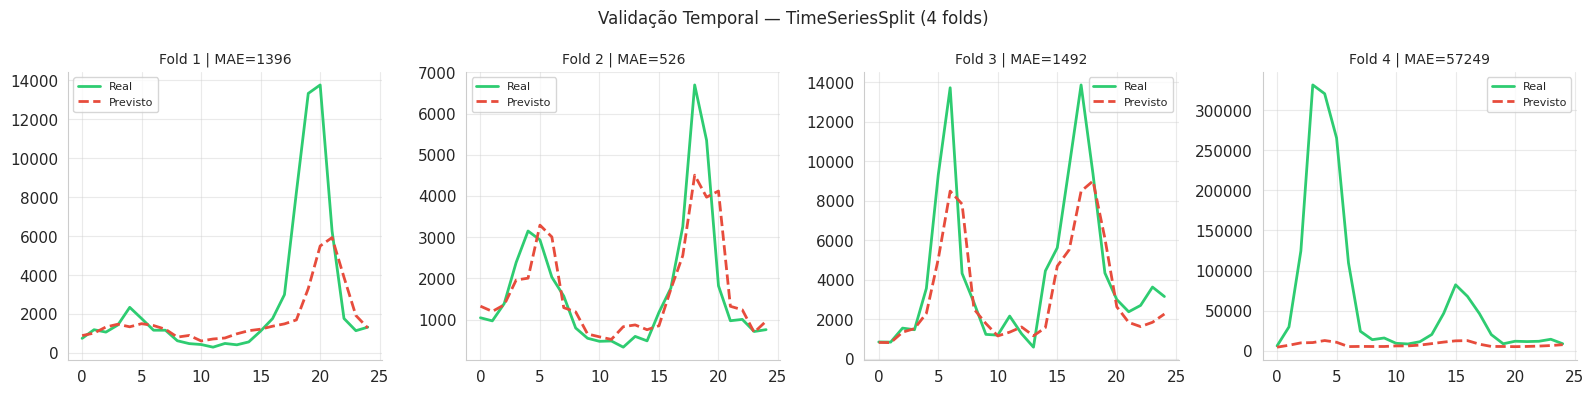


MAE médio: 15166 casos/mês
Modelo salvo: modelo_dengue_sp.pkl


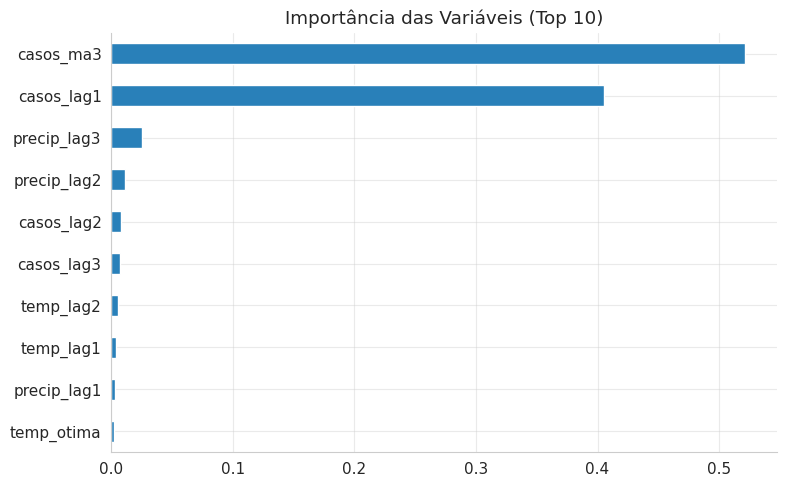

In [ ]:
# ── Treino com TimeSeriesSplit ─────────────────────────
modelo = RandomForestRegressor(n_estimators=200, max_depth=6,
    min_samples_leaf=2, random_state=42, n_jobs=-1)

tscv = TimeSeriesSplit(n_splits=4)
cv_res = []

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Validação Temporal — TimeSeriesSplit (4 folds)', fontsize=12)

for fold, (tr, te) in enumerate(tscv.split(X)):
    modelo.fit(X.iloc[tr], y.iloc[tr])
    pred = modelo.predict(X.iloc[te])
    mae  = mean_absolute_error(y.iloc[te], pred)
    cv_res.append({'Fold': fold+1, 'MAE': round(mae, 0)})
    axes[fold].plot(y.iloc[te].values, color='#2ecc71', label='Real', lw=2)
    axes[fold].plot(pred, color='#e74c3c', ls='--', label='Previsto', lw=2)
    axes[fold].set_title(f'Fold {fold+1} | MAE={mae:.0f}', fontsize=10)
    axes[fold].legend(fontsize=8); axes[fold].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('validacao_modelo.png', dpi=150, bbox_inches='tight')
plt.show()

modelo.fit(X, y)
joblib.dump(modelo, 'modelo_dengue_sp.pkl')
df_res = pd.DataFrame(cv_res)
print(f'\nMAE médio: {df_res.MAE.mean():.0f} casos/mês')
print(f'Modelo salvo: modelo_dengue_sp.pkl')

imp = pd.Series(modelo.feature_importances_, index=FEATURES).sort_values(ascending=False)
fig2, ax2 = plt.subplots(figsize=(8, 5))
imp.head(10).sort_values().plot(kind='barh', ax=ax2, color='#2980b9', edgecolor='white')
ax2.set_title('Importância das Variáveis (Top 10)')
ax2.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('importancia.png', dpi=150, bbox_inches='tight'); plt.show()

In [ ]:
# ── Previsão dos próximos 6 meses ─────────────────────
def prever(df_feat, modelo, features, n=6):
    d = df_feat.copy()
    previsoes = []
    for i in range(1, n+1):
        ultima = d.iloc[-1]
        mes_fut = (int(ultima['mes']) % 12) + 1
        ano_fut = int(ultima['ano']) + (1 if mes_fut == 1 else 0)
        nova = {
            'mes': mes_fut, 'ano': ano_fut,
            'casos_lag1': d['casos'].iloc[-1],
            'casos_lag2': d['casos'].iloc[-2],
            'casos_lag3': d['casos'].iloc[-3],
            'casos_ma3' : d['casos'].tail(3).mean(),
            'temp_lag1' : d['temp_media'].iloc[-1],
            'temp_lag2' : d['temp_media'].iloc[-2],
            'temp_lag3' : d['temp_media'].iloc[-3],
            'precip_lag1': d['precip_mm'].iloc[-1],
            'precip_lag2': d['precip_mm'].iloc[-2],
            'precip_lag3': d['precip_mm'].iloc[-3],
            'temp_otima' : int(d['temp_media'].iloc[-1] > 20),
            'seno_mes'   : np.sin(2*np.pi*mes_fut/12),
            'cosseno_mes': np.cos(2*np.pi*mes_fut/12),
        }
        X_fut = pd.DataFrame([nova])[features].fillna(0)
        casos_pred = max(0, modelo.predict(X_fut)[0])
        amostras   = [max(0, casos_pred*(1+np.random.normal(0,0.18))) for _ in range(300)]
        inc = casos_pred / POP_SP * 100_000
        alerta = '🔴 Alto' if inc>1200 else '🟡 Moderado' if inc>400 else '🟢 Baixo'
        previsoes.append({
            'Mês/Ano'  : f'{MESES[mes_fut-1]}/{ano_fut}',
            'Casos'    : int(casos_pred),
            'IC_lower' : int(np.percentile(amostras, 10)),
            'IC_upper' : int(np.percentile(amostras, 90)),
            'Alerta'   : alerta,
        })
        nova['casos'] = casos_pred; nova['temp_media'] = d['temp_media'].iloc[-1]
        nova['precip_mm'] = d['precip_mm'].iloc[-1]; nova['data'] = pd.Timestamp(f'{ano_fut}-{mes_fut:02d}-01')
        d = pd.concat([d, pd.DataFrame([nova])], ignore_index=True)
    return pd.DataFrame(previsoes)

df_prev = prever(df_feat, modelo, FEATURES, n=6)
df_prev.to_csv('previsoes_6meses.csv', index=False)
print('📅 PREVISÃO — PRÓXIMOS 6 MESES:')
print(df_prev.to_string(index=False))

📅 PREVISÃO — PRÓXIMOS 6 MESES:
 Mês/Ano  Casos  IC_lower  IC_upper  Alerta
Jan/2026  20538     16095     25261 🟢 Baixo
Fev/2026  28047     21239     34134 🟢 Baixo
Mar/2026  35928     28685     45127 🟢 Baixo
Abr/2026  42821     33181     53345 🟢 Baixo
Mai/2026  42868     34666     54393 🟢 Baixo
Jun/2026  43978     34498     53438 🟢 Baixo


In [ ]:
from IPython.display import HTML
import json

# ── Pré-calcular TODOS os JSONs ──────────────────────────
# Série temporal mensal
hist_datas_js  = json.dumps(df['data'].dt.strftime('%Y-%m').tolist())
hist_casos_js  = json.dumps(df['casos'].astype(int).tolist())
hist_temp_js   = json.dumps(df['temp_media'].round(1).tolist())
hist_precip_js = json.dumps(df['precip_mm'].round(1).tolist())
hist_alerta_js = json.dumps(df['alerta'].tolist())

# Sazonalidade
sazo_final = df.groupby('mes')[['casos','temp_media','precip_mm']].mean().reindex(range(1,13), fill_value=0)
sazo_casos_js  = json.dumps([round(x) for x in sazo_final['casos'].tolist()])
sazo_temp_js   = json.dumps([round(x,1) for x in sazo_final['temp_media'].tolist()])
sazo_precip_js = json.dumps([round(x,1) for x in sazo_final['precip_mm'].tolist()])
meses_js       = json.dumps(MESES)

# Correlação por lag
corr_temp_js   = json.dumps(df_corr[df_corr['Variável']=='Temperatura']['r (Spearman)'].tolist())
corr_precip_js = json.dumps(df_corr[df_corr['Variável']=='Precipitação']['r (Spearman)'].tolist())

# Importância das variáveis
imp_top = imp.head(10).sort_values(ascending=False)
imp_nomes_js  = json.dumps(imp_top.index.tolist())
imp_vals_js   = json.dumps([round(float(v),4) for v in imp_top.values])

# Previsão
prev_meses_js  = json.dumps(df_prev['Mês/Ano'].tolist())
prev_casos_js  = json.dumps(df_prev['Casos'].tolist())
prev_lower_js  = json.dumps(df_prev['IC_lower'].tolist())
prev_upper_js  = json.dumps(df_prev['IC_upper'].tolist())
prev_alerta_js = json.dumps(df_prev['Alerta'].tolist())

# Heatmap ano × mês
pivot_heat = df.groupby(['ano','mes'])['casos'].sum().unstack().fillna(0)
heat_anos_js = json.dumps([int(a) for a in pivot_heat.index.tolist()])
heat_data_js = json.dumps([[int(v) for v in row] for row in pivot_heat.values.tolist()])

# KPIs
total_casos   = f"{int(df['casos'].sum()):,}".replace(",",".")
ano_pico_kpi  = int(df.groupby('ano')['casos'].sum().idxmax())
casos_pico_kpi = f"{int(df[df['ano']==ano_pico_kpi]['casos'].sum()):,}".replace(",",".")
mae_medio     = f"{pd.DataFrame(cv_res).MAE.mean():.0f}"
media_temp     = f"{df['temp_media'].mean():.1f}"

# Distritos (mapa)
dist_js = json.dumps(distritos)

html = f"""
<!DOCTYPE html>
<html lang="pt-BR">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Dashboard Dengue SP 2015–2025</title>
<script src="https://cdn.jsdelivr.net/npm/chart.js@4.4.1/dist/chart.umd.min.js"></script>
<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>
<style>
  @import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700&display=swap');
  * {{ margin:0; padding:0; box-sizing:border-box; }}
  body {{ font-family:'Inter',sans-serif; background:#0f1117; color:#e0e0e0; }}

  .header {{
    background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
    padding: 32px 40px 24px;
    border-bottom: 3px solid #e74c3c;
  }}
  .header h1 {{ font-size:28px; font-weight:700; color:#fff; }}
  .header h1 span {{ color:#e74c3c; }}
  .header p {{ color:#8899aa; font-size:14px; margin-top:6px; }}
  .header .badge {{
    display:inline-block; background:#e74c3c; color:#fff;
    padding:4px 12px; border-radius:20px; font-size:12px;
    font-weight:600; margin-left:12px; vertical-align:middle;
  }}

  .container {{ max-width:1400px; margin:0 auto; padding:24px 20px; }}

  /* KPIs */
  .kpis {{ display:grid; grid-template-columns:repeat(auto-fit,minmax(220px,1fr)); gap:16px; margin-bottom:28px; }}
  .kpi {{
    background: linear-gradient(135deg, #1e2330, #252a3a);
    border-radius:12px; padding:20px 24px;
    border-left:4px solid #e74c3c;
    transition: transform .2s;
  }}
  .kpi:hover {{ transform: translateY(-3px); }}
  .kpi:nth-child(2) {{ border-left-color:#f39c12; }}
  .kpi:nth-child(3) {{ border-left-color:#3498db; }}
  .kpi:nth-child(4) {{ border-left-color:#27ae60; }}
  .kpi .label {{ font-size:12px; color:#8899aa; text-transform:uppercase; letter-spacing:1px; }}
  .kpi .value {{ font-size:30px; font-weight:700; color:#fff; margin:6px 0 4px; }}
  .kpi .sub {{ font-size:12px; color:#6b7b8d; }}

  /* Grid de charts */
  .grid {{ display:grid; gap:20px; margin-bottom:24px; }}
  .grid-2 {{ grid-template-columns: 1fr 1fr; }}
  .grid-3 {{ grid-template-columns: 1fr 1fr 1fr; }}
  .grid-1 {{ grid-template-columns: 1fr; }}

  .card {{
    background: #1a1f2e;
    border-radius:12px; padding:20px;
    border: 1px solid #2a3040;
  }}
  .card h3 {{
    font-size:14px; font-weight:600; color:#fff;
    margin-bottom:4px;
  }}
  .card .subtitle {{ font-size:11px; color:#6b7b8d; margin-bottom:16px; text-transform:uppercase; letter-spacing:0.5px; }}

  canvas {{ max-height: 320px; }}

  /* Tabela previsão */
  .prev-table {{ width:100%; border-collapse:collapse; font-size:13px; }}
  .prev-table th {{
    background:#252a3a; color:#8899aa; padding:10px 14px;
    text-align:left; font-weight:600; text-transform:uppercase;
    font-size:11px; letter-spacing:0.5px;
  }}
  .prev-table td {{ padding:10px 14px; border-bottom:1px solid #2a3040; }}
  .prev-table tr:hover {{ background:#252a3a; }}
  .alert-tag {{
    padding:3px 10px; border-radius:12px; font-size:11px; font-weight:600;
  }}
  .alert-alto {{ background:rgba(231,76,60,0.2); color:#e74c3c; }}
  .alert-moderado {{ background:rgba(243,156,18,0.2); color:#f39c12; }}
  .alert-baixo {{ background:rgba(39,174,96,0.2); color:#27ae60; }}

  #mapa {{ height:380px; border-radius:10px; }}

  .footer {{
    text-align:center; padding:20px; color:#4a5568; font-size:12px;
    border-top:1px solid #2a3040; margin-top:20px;
  }}
  .footer a {{ color:#3498db; text-decoration:none; }}

  @media (max-width:900px) {{
    .grid-2, .grid-3 {{ grid-template-columns:1fr; }}
    .kpis {{ grid-template-columns:repeat(2,1fr); }}
  }}
</style>
</head>
<body>

<div class="header">
  <h1>&#129415; Dengue <span>São Paulo</span>
    <span class="badge">2015 – 2025</span>
  </h1>
  <p>Análise de correlação climática &amp; previsão com Random Forest — Dados: InfoDengue / IAG-USP</p>
</div>

<div class="container">

  <!-- KPIs -->
  <div class="kpis">
    <div class="kpi">
      <div class="label">Total de Casos</div>
      <div class="value">{total_casos}</div>
      <div class="sub">2015 – 2025 · município de SP</div>
    </div>
    <div class="kpi">
      <div class="label">Ano de Pico</div>
      <div class="value">{ano_pico_kpi}</div>
      <div class="sub">{casos_pico_kpi} casos no ano</div>
    </div>
    <div class="kpi">
      <div class="label">MAE do Modelo</div>
      <div class="value">{mae_medio}</div>
      <div class="sub">casos/mês · Random Forest</div>
    </div>
    <div class="kpi">
      <div class="label">Temp. Média</div>
      <div class="value">{media_temp}°C</div>
      <div class="sub">média do período · IAG/USP</div>
    </div>
  </div>

  <!-- Linha 1: Série temporal -->
  <div class="grid grid-1">
    <div class="card">
      <h3>&#128200; Série Temporal — Casos Mensais de Dengue</h3>
      <div class="subtitle">Barras coloridas por nível de alerta · Linha vermelha: previsão 6 meses</div>
      <canvas id="chartSerie"></canvas>
    </div>
  </div>

  <!-- Linha 2: Sazonalidade + Correlação -->
  <div class="grid grid-2">
    <div class="card">
      <h3>&#128197; Sazonalidade Mensal</h3>
      <div class="subtitle">Média de casos, temperatura e precipitação por mês</div>
      <canvas id="chartSazo"></canvas>
    </div>
    <div class="card">
      <h3>&#128300; Correlação de Spearman por Lag</h3>
      <div class="subtitle">Temperatura e precipitação vs. casos · lag 0–3 meses</div>
      <canvas id="chartCorr"></canvas>
    </div>
  </div>

  <!-- Linha 3: Importância + Previsão tabela -->
  <div class="grid grid-2">
    <div class="card">
      <h3>&#127942; Importância das Variáveis</h3>
      <div class="subtitle">Random Forest · Top 10 features</div>
      <canvas id="chartImp"></canvas>
    </div>
    <div class="card">
      <h3>&#128197; Previsão — Próximos 6 Meses</h3>
      <div class="subtitle">Modelo Random Forest + Intervalo de Confiança 80%</div>
      <table class="prev-table">
        <thead><tr><th>Mês/Ano</th><th>Casos</th><th>IC 80%</th><th>Alerta</th></tr></thead>
        <tbody id="tblPrev"></tbody>
      </table>
    </div>
  </div>

  <!-- Linha 4: Heatmap + Mapa -->
  <div class="grid grid-2">
    <div class="card">
      <h3>&#128293; Heatmap — Casos por Ano × Mês</h3>
      <div class="subtitle">Intensidade de cor proporcional ao número de casos</div>
      <canvas id="chartHeat"></canvas>
    </div>
    <div class="card">
      <h3>&#128205; Mapa de Vulnerabilidade — Distritos</h3>
      <div class="subtitle">Estimativa de risco relativo por região</div>
      <div id="mapa"></div>
    </div>
  </div>

</div>

<div class="footer">
  Fontes: <a href="https://info.dengue.mat.br" target="_blank">InfoDengue</a> ·
  <a href="https://www.prefeitura.sp.gov.br" target="_blank">Prefeitura SP / IAG-USP</a> ·
  <a href="https://bdmep.inmet.gov.br/" target="_blank">INMET</a><br>
  Gerado automaticamente pelo notebook · dados até {df['data'].max().strftime('%d/%m/%Y')}
</div>

<script>
// ── Dados injetados ──────────────────────────────────
const datas    = {hist_datas_js};
const casos    = {hist_casos_js};
const temp     = {hist_temp_js};
const precip   = {hist_precip_js};
const alertas  = {hist_alerta_js};
const meses    = {meses_js};
const sazoCasos  = {sazo_casos_js};
const sazoTemp   = {sazo_temp_js};
const sazoPrecip = {sazo_precip_js};
const corrTemp   = {corr_temp_js};
const corrPrecip = {corr_precip_js};
const impNomes   = {imp_nomes_js};
const impVals    = {imp_vals_js};
const prevMeses  = {prev_meses_js};
const prevCasos  = {prev_casos_js};
const prevLower  = {prev_lower_js};
const prevUpper  = {prev_upper_js};
const prevAlerta = {prev_alerta_js};
const heatAnos   = {heat_anos_js};
const heatData   = {heat_data_js};
const distritos  = {dist_js};

Chart.defaults.color = '#8899aa';
Chart.defaults.borderColor = '#2a3040';
const fontOpts = {{ family: 'Inter, sans-serif' }};

// ── Série temporal ───────────────────────────────────
const corMap = {{'🟢 Baixo':'#27ae60','🟡 Moderado':'#f39c12','🔴 Alto':'#e74c3c'}};
const bgCores = casos.map((c,i) => corMap[alertas[i]] || '#3498db');

new Chart(document.getElementById('chartSerie'), {{
  type: 'bar',
  data: {{
    labels: datas,
    datasets: [
      {{ label:'Casos', data:casos, backgroundColor:bgCores, borderRadius:3 }},
      {{ label:'Previsão', data: Array(datas.length).fill(null).concat(prevCasos),
         type:'line', borderColor:'#e74c3c', borderWidth:2.5, borderDash:[6,4],
         pointBackgroundColor:'#e74c3c', pointRadius:5, tension:0.3 }}
    ]
  }},
  options: {{
    responsive:true, plugins:{{ legend:{{ labels:{{ font:fontOpts }} }} }},
    scales: {{
      x: {{ ticks:{{ maxTicksLimit:20, font:fontOpts }} }},
      y: {{ ticks:{{ font:fontOpts }}, title:{{ display:true, text:'Casos', font:fontOpts }} }}
    }}
  }}
}});

// ── Sazonalidade ─────────────────────────────────────
new Chart(document.getElementById('chartSazo'), {{
  data: {{
    labels: meses,
    datasets: [
      {{ type:'bar', label:'Casos médios', data:sazoCasos, backgroundColor:'rgba(231,76,60,0.6)',
         borderRadius:4, yAxisID:'y' }},
      {{ type:'bar', label:'Precipitação (mm)', data:sazoPrecip, backgroundColor:'rgba(52,152,219,0.4)',
         borderRadius:4, yAxisID:'y' }},
      {{ type:'line', label:'Temperatura (°C)', data:sazoTemp, borderColor:'#f39c12',
         borderWidth:2.5, pointRadius:5, pointBackgroundColor:'#f39c12', tension:0.3, yAxisID:'y1' }}
    ]
  }},
  options: {{
    responsive:true,
    plugins:{{ legend:{{ labels:{{ font:fontOpts }} }} }},
    scales: {{
      y:  {{ position:'left', ticks:{{ font:fontOpts }}, title:{{ display:true, text:'Casos / mm', font:fontOpts }} }},
      y1: {{ position:'right', grid:{{ drawOnChartArea:false }}, ticks:{{ font:fontOpts }},
             title:{{ display:true, text:'°C', font:fontOpts }}, min:14, max:26 }}
    }}
  }}
}});

// ── Correlação ───────────────────────────────────────
new Chart(document.getElementById('chartCorr'), {{
  type: 'line',
  data: {{
    labels: ['Lag 0','Lag 1','Lag 2','Lag 3'],
    datasets: [
      {{ label:'Temperatura', data:corrTemp, borderColor:'#e74c3c', backgroundColor:'rgba(231,76,60,0.1)',
         fill:true, borderWidth:2.5, pointRadius:7, pointBackgroundColor:'#e74c3c', tension:0.3 }},
      {{ label:'Precipitação', data:corrPrecip, borderColor:'#3498db', backgroundColor:'rgba(52,152,219,0.1)',
         fill:true, borderWidth:2.5, pointRadius:7, pointBackgroundColor:'#3498db', tension:0.3 }}
    ]
  }},
  options: {{
    responsive:true,
    plugins: {{
      legend:{{ labels:{{ font:fontOpts }} }},
      annotation: {{ annotations: {{ line0: {{ type:'line', yMin:0, yMax:0, borderColor:'#555', borderWidth:1 }} }} }}
    }},
    scales: {{
      y: {{ min:-0.6, max:0.8, ticks:{{ font:fontOpts }}, title:{{ display:true, text:'r (Spearman)', font:fontOpts }} }},
      x: {{ ticks:{{ font:fontOpts }} }}
    }}
  }}
}});

// ── Importância ──────────────────────────────────────
new Chart(document.getElementById('chartImp'), {{
  type: 'bar',
  data: {{
    labels: impNomes,
    datasets: [{{ data:impVals, backgroundColor:'#2980b9', borderRadius:4 }}]
  }},
  options: {{
    indexAxis:'y', responsive:true,
    plugins:{{ legend:{{ display:false }} }},
    scales: {{
      x: {{ ticks:{{ font:fontOpts }}, title:{{ display:true, text:'Importância', font:fontOpts }} }},
      y: {{ ticks:{{ font:fontOpts }} }}
    }}
  }}
}});

// ── Tabela de previsão ───────────────────────────────
const tbody = document.getElementById('tblPrev');
prevMeses.forEach((m, i) => {{
  const cls = prevAlerta[i].includes('Alto') ? 'alto' : prevAlerta[i].includes('Moderado') ? 'moderado' : 'baixo';
  const ico = prevAlerta[i].includes('Alto') ? '🔴' : prevAlerta[i].includes('Moderado') ? '🟡' : '🟢';
  tbody.innerHTML += `<tr>
    <td style="font-weight:600">${{m}}</td>
    <td>${{prevCasos[i].toLocaleString('pt-BR')}}</td>
    <td style="color:#6b7b8d">${{prevLower[i].toLocaleString('pt-BR')}} – ${{prevUpper[i].toLocaleString('pt-BR')}}</td>
    <td><span class="alert-tag alert-${{cls}}">${{ico}} ${{cls.charAt(0).toUpperCase()+cls.slice(1)}}</span></td>
  </tr>`;
}});

// ── Heatmap (canvas manual) ──────────────────────────
(function() {{
  const cv = document.getElementById('chartHeat');
  const ctx = cv.getContext('2d');
  const W = cv.parentElement.clientWidth - 40;
  const rows = heatAnos.length, cols = 12;
  const pad = {{ top:10, left:50, right:20, bottom:30 }};
  const cw = (W - pad.left - pad.right) / cols;
  const ch = Math.min(32, (300 - pad.top - pad.bottom) / rows);
  cv.width = W; cv.height = pad.top + rows*ch + pad.bottom;
  ctx.font = '11px Inter, sans-serif';

  let maxVal = 0;
  heatData.forEach(r => r.forEach(v => {{ if(v > maxVal) maxVal = v; }}));

  for(let r=0; r<rows; r++) {{
    for(let c=0; c<cols; c++) {{
      const v = heatData[r][c];
      const t = maxVal > 0 ? v / maxVal : 0;
      const red = Math.round(255 * Math.min(1, t * 2));
      const green = Math.round(255 * Math.max(0, 1 - t * 1.5));
      ctx.fillStyle = `rgba(${{red}},${{green}},50,${{0.3 + t*0.7}})`;
      ctx.fillRect(pad.left + c*cw, pad.top + r*ch, cw-2, ch-2);
      if(cw > 38) {{
        ctx.fillStyle = t > 0.5 ? '#fff' : '#aaa';
        ctx.textAlign = 'center';
        ctx.fillText(v.toLocaleString('pt-BR'), pad.left + c*cw + cw/2, pad.top + r*ch + ch/2 + 4);
      }}
    }}
    ctx.fillStyle = '#8899aa'; ctx.textAlign = 'right';
    ctx.fillText(heatAnos[r], pad.left - 8, pad.top + r*ch + ch/2 + 4);
  }}
  const ml = {meses_js};
  for(let c=0; c<12; c++) {{
    ctx.fillStyle = '#8899aa'; ctx.textAlign = 'center';
    ctx.fillText(ml[c], pad.left + c*cw + cw/2, pad.top + rows*ch + 18);
  }}
}})();

// ── Mapa Leaflet ─────────────────────────────────────
const map = L.map('mapa', {{ zoomControl:false }}).setView([-23.5505, -46.6333], 11);
L.tileLayer('https://{{s}}.basemaps.cartocdn.com/dark_all/{{z}}/{{x}}/{{y}}{{r}}.png', {{
  attribution: '© CartoDB', maxZoom: 18
}}).addTo(map);

distritos.forEach(d => {{
  const cor = d.vuln > 0.7 ? '#e74c3c' : d.vuln > 0.5 ? '#f39c12' : '#27ae60';
  L.circleMarker([d.lat, d.lon], {{
    radius: 6 + d.vuln * 12, color: '#fff', weight:1,
    fillColor: cor, fillOpacity: 0.8
  }}).bindTooltip(`<b>${{d.nome}}</b><br>Vulnerabilidade: ${{(d.vuln*100).toFixed(0)}}%`, {{
    className: 'custom-tooltip'
  }}).addTo(map);
}});

</script>
</body>
</html>
"""

# Salva na pasta site/ para Vercel
import os
os.makedirs('site', exist_ok=True)
with open('site/index.html', 'w', encoding='utf-8') as f:
    f.write(html)

print('✅ Dashboard salvo em site/index.html')
HTML(html)

💾 Dashboard salvo: dashboard_dengue_sp.html


In [ ]:
distritos = [
    {'nome':'Sé',           'lat':-23.5505,'lon':-46.6333,'vuln':0.40},
    {'nome':'Pinheiros',    'lat':-23.5629,'lon':-46.6944,'vuln':0.20},
    {'nome':'Mooca',        'lat':-23.5551,'lon':-46.5997,'vuln':0.50},
    {'nome':'Santana',      'lat':-23.4983,'lon':-46.6267,'vuln':0.30},
    {'nome':'Pirituba',     'lat':-23.4744,'lon':-46.7264,'vuln':0.60},
    {'nome':'Perus',        'lat':-23.4103,'lon':-46.7394,'vuln':0.70},
    {'nome':'Grajaú',       'lat':-23.7167,'lon':-46.6833,'vuln':0.85},
    {'nome':'Cidade Ademar','lat':-23.6739,'lon':-46.6553,'vuln':0.75},
    {'nome':'Campo Limpo',  'lat':-23.6300,'lon':-46.7400,'vuln':0.70},
    {'nome':'M Boi Mirim',  'lat':-23.6872,'lon':-46.7564,'vuln':0.85},
    {'nome':'Capão Redondo','lat':-23.6631,'lon':-46.7817,'vuln':0.80},
    {'nome':'Itaquera',     'lat':-23.5400,'lon':-46.4564,'vuln':0.65},
    {'nome':'São Mateus',   'lat':-23.5961,'lon':-46.4608,'vuln':0.70},
    {'nome':'Guaianases',   'lat':-23.5411,'lon':-46.3897,'vuln':0.75},
    {'nome':'Penha',        'lat':-23.5233,'lon':-46.5319,'vuln':0.55},
    {'nome':'Ipiranga',     'lat':-23.5908,'lon':-46.6033,'vuln':0.45},
    {'nome':'Jabaquara',    'lat':-23.6428,'lon':-46.6428,'vuln':0.50},
]
df_dist = pd.DataFrame(distritos)
ano_pico   = df.groupby('ano')['casos'].sum().idxmax()
casos_pico = df[df['ano']==ano_pico]['casos'].sum()
print(f'Ano de pico: {ano_pico} ({casos_pico:,.0f} casos)')

m = folium.Map(location=[-23.5505,-46.6333], zoom_start=11, tiles='CartoDB dark_matter')
heat = [[r.lat, r.lon, r.vuln*casos_pico/8000] for r in df_dist.itertuples()]
HeatMap(heat, radius=38, blur=28, gradient={0.2:'blue',0.5:'yellow',0.8:'orange',1.0:'red'}).add_to(m)

for r in df_dist.itertuples():
    est = int(r.vuln * casos_pico / len(df_dist) * 1.5)
    cor = 'red' if r.vuln>0.7 else 'orange' if r.vuln>0.5 else 'green'
    folium.CircleMarker([r.lat,r.lon], radius=6, color='white',
        fill=True, fill_color=cor, fill_opacity=0.85,
        tooltip=f'<b>{r.nome}</b><br>Vulnerabilidade: {r.vuln:.0%}<br>Casos est.: {est:,}'
    ).add_to(m)

m.get_root().html.add_child(folium.Element(
    f'<div style="position:fixed;top:10px;left:50%;transform:translateX(-50%);'
    f'background:rgba(0,0,0,0.75);color:white;padding:10px 18px;border-radius:8px;'
    f'font-size:14px;z-index:1000;">🦟 Mapa de Risco — Dengue SP {ano_pico}</div>'))
m.save('mapa_dengue_sp.html')
print('✅ Mapa salvo: mapa_dengue_sp.html')
from IPython.display import IFrame
IFrame('mapa_dengue_sp.html', width=900, height=480)

Ano de pico: 2024 (1,264,130 casos)
✅ Mapa salvo: mapa_dengue_sp.html


Fontes:

Casos Dengue SP: https://saude.sp.gov.br/cve-centro-de-vigilancia-epidemiologica-prof.-alexandre-vranjac/areas-de-vigilancia/doencas-de-transmissao-por-vetores-e-zoonoses/arboviroses-urbanas/dengue-dados-estatisticos

Temperatura média SP: https://drive.prefeitura.sp.gov.br/cidade/secretarias/upload/chamadas/temp_mdia-precipitacao_1650654282.htm

Dados meteorológicos: https://bdmep.inmet.gov.br/